# JUG: Building a Timing Model

Radio pulses are dispersed by the interstellar medium: lower frequencies arrive later by
$$\tau_{\rm DM} = \frac{K_{\rm DM} \cdot DM(t)}{f^2}$$
where $K_{\rm DM} \approx 4150\,\mu{\rm s}\cdot{\rm pc}^{-1}\,{\rm cm}^3\,{\rm GHz}^2$.

$DM(t)$ is not constant — the line of sight through the ISM shifts as the pulsar moves and
the Earth orbits.  Failing to track this drift leaves correlated residuals.

This notebook fits **four versions** of the same dataset, progressively improving the DM model:

| Stage | DM model | Free params added |
|-------|----------|-------------------|
| 1 | Constant DM | — |
| 2 | Linear drift | `DM1` |
| 3 | Quadratic drift | `DM1` + `DM2` |
| 4 | Epoch-by-epoch (DMX) | 288 DMX ranges (NANOGrav 15yr) |

A single base par file is loaded fresh for each stage; `session.set_free()` enables
additional parameters without touching the file.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from jug.engine.session import TimingSession

TIM      = "../data/pulsars/NG_15yr_partim/J1909-3744_PINT_20220303.nb.tim"
FULL_PAR = "../data/pulsars/NG_15yr_partim/J1909-3744_PINT_20220303.nb.par"
CLOCK    = "../data/clock"

> **Performance note:** The first execution compiles JAX kernels for this machine (~1–3 minutes).
> Subsequent runs use the on-disk compilation cache and complete in seconds.
> Run this notebook once before your presentation to warm the cache.

## Build the base par file

One stripped par: correct binary + astrometry from the NANOGrav 15yr fit, constant DM,
`DM1 = DM2 = 0` (frozen), no DMX, no noise model.
Each stage reloads this file and calls `set_free()` to enable extra parameters.

In [2]:
BASE_PAR = "/tmp/j1909_base.par"

with open(BASE_PAR, 'w') as _f:
    _f.write("""\
PSR                            J1909-3744
EPHEM                               DE440
CLOCK                        TT(BIPM2019)
UNITS                                 TDB
TIMEEPH                              FB90
T2CMETHOD                        IAU2000B
DILATEFREQ                              N
DMDATA                                  N
ELONG                 284.220845879968067 1 0.00000000135348924677
ELAT                  -15.155533209547460 1 0.00000000574881974259
PMELONG               -13.869921797237843 1 0.0011360765706638126
PMELAT                 -34.31363260467267 1 0.004865798828486848
PX                     0.8909370620938715 1 0.015591217917650444
ECL                              IERS2010
POSEPOCH           56121.0
F0                  339.31569232322724258 1 2.1538817549731577267e-13
F1              -1.6148082400121533993e-15 1 8.0637417649310651885e-21
PEPOCH             56121.0
CORRECT_TROPOSPHERE                         Y
PLANET_SHAPIRO                          Y
NE_SW                                 0.0
SWM                                   0.0
DM                  10.391172219228799625
DMEPOCH            56121.0
DM1                        0.0
DM2                        0.0
BINARY                                ELL1
PB                   1.533449452063739542 1 1.3057321055536540108e-12
PBDOT               5.089299326991869e-13 1 1.4399748743439648e-15
A1                     1.8979910123004033 1 2.4995385183686275e-08
A1DOT              -1.961179489321809e-16 1 5.468401872783086e-17
M2                    0.20869663583955864 1 0.0014841739630777155
SINI                   0.9980132225981544 1 6.663486559271068e-05
TASC               56121.0449614186454710 1 1.1490020209053259836e-09
EPS1             4.456893441219944197e-08 1 1.20091822756217453315e-08
EPS2            -9.905628418978287241e-08 1 6.647524161803488383e-09
FD1                -8.745123917490766e-07 1 2.6412628818848836e-08
JUMP            -fe Rcvr1_2   -1.7779358227913764e-05 1 2.3007603743850887e-08
JUMP            -fe Rcvr_800   -1.9499318955542175e-05 1 2.7513739723799897e-08
TZRMJD             55616.4902797730193403
TZRSITE                                GB
TZRFRQ                           1780.479
""")

print(f"Base par written to {BASE_PAR}")

Base par written to /tmp/j1909_base.par


## Stage 1 — Constant DM

Fit all timing parameters (astrometry, spin, binary, FD, JUMPs) but hold DM fixed.
The residuals will show whatever DM variation is not captured by a single constant.

In [3]:
import time

s1 = TimingSession(BASE_PAR, TIM, clock_dir=CLOCK, verbose=False)
print("Free params:", s1.free_params)
t0 = time.perf_counter()
fit1 = s1.fit_parameters(max_iter=3, verbose=False)
print(f"Stage 1 done — {time.perf_counter()-t0:.1f}s  "
      f"RMS = {np.sqrt(np.mean(np.array(fit1['residuals_us'])**2)):.3f} µs  "
      f"({fit1['iterations']} iters)")

Free params: ['A1', 'A1DOT', 'ELAT', 'ELONG', 'EPS1', 'EPS2', 'F0', 'F1', 'FD1', 'JUMP1', 'JUMP2', 'M2', 'PB', 'PBDOT', 'PMELAT', 'PMELONG', 'PX', 'SINI', 'TASC']


[!] Unrecognized par file parameters (ignored by JUG): CLOCK, DMDATA, ECL


[FITTER] noise_config was None, auto-detecting from par file


Stage 1 done — 33.4s  RMS = 1.698 µs  (3 iters)


## Stage 2 — Add DM₁ (linear drift)

Enable `DM1` with `session.set_free()` — no par file editing needed.  The linear drift
$DM(t) = DM_0 + DM_1 \cdot (t - t_{\rm DMEPOCH})$ removes the dominant ramp.

In [4]:
s2 = TimingSession(BASE_PAR, TIM, clock_dir=CLOCK, verbose=False)
s2.set_free('DM1')  # enable linear DM drift
print("Free params:", s2.free_params)
t0 = time.perf_counter()
fit2 = s2.fit_parameters(max_iter=3, verbose=False)
dm1_fitted = fit2['final_params']['DM1']
print(f"Stage 2 done — {time.perf_counter()-t0:.1f}s  "
      f"RMS = {np.sqrt(np.mean(np.array(fit2['residuals_us'])**2)):.3f} µs  "
      f"DM1 = {dm1_fitted:.4e} pc cm⁻³ yr⁻¹")

Free params: ['A1', 'A1DOT', 'DM1', 'ELAT', 'ELONG', 'EPS1', 'EPS2', 'F0', 'F1', 'FD1', 'JUMP1', 'JUMP2', 'M2', 'PB', 'PBDOT', 'PMELAT', 'PMELONG', 'PX', 'SINI', 'TASC']


[!] Unrecognized par file parameters (ignored by JUG): CLOCK, DMDATA, ECL


[FITTER] noise_config was None, auto-detecting from par file


Stage 2 done — 21.0s  RMS = 1.249 µs  DM1 = -1.7211e-04 pc cm⁻³ yr⁻¹


## Stage 3 — Add DM₂ (quadratic drift)

Also enable `DM2`.  The quadratic term captures curvature in the DM time series.

In [5]:
s3 = TimingSession(BASE_PAR, TIM, clock_dir=CLOCK, verbose=False)
s3.set_free('DM1', 'DM2')  # enable linear + quadratic DM drift
print("Free params:", s3.free_params)
t0 = time.perf_counter()
fit3 = s3.fit_parameters(max_iter=3, verbose=False)
dm2_fitted = fit3['final_params']['DM2']
print(f"Stage 3 done — {time.perf_counter()-t0:.1f}s  "
      f"RMS = {np.sqrt(np.mean(np.array(fit3['residuals_us'])**2)):.3f} µs  "
      f"DM2 = {dm2_fitted:.4e} pc cm⁻³ yr⁻²")

Free params: ['A1', 'A1DOT', 'DM1', 'DM2', 'ELAT', 'ELONG', 'EPS1', 'EPS2', 'F0', 'F1', 'FD1', 'JUMP1', 'JUMP2', 'M2', 'PB', 'PBDOT', 'PMELAT', 'PMELONG', 'PX', 'SINI', 'TASC']


[!] Unrecognized par file parameters (ignored by JUG): CLOCK, DMDATA, ECL


[FITTER] noise_config was None, auto-detecting from par file


Stage 3 done — 21.1s  RMS = 1.234 µs  DM2 = 1.5590e-05 pc cm⁻³ yr⁻²


## Stage 4 — DMX (NANOGrav default)

Load the full NANOGrav par file.  This has 288 DMX ranges (one per ~30-day epoch)
fit jointly with the timing parameters via augmented GLS — no separate step needed.

In [6]:
s4 = TimingSession(FULL_PAR, TIM, clock_dir=CLOCK, verbose=False)
t0 = time.perf_counter()
fit4 = s4.fit_parameters(max_iter=3, verbose=False)
n_dmx = sum(1 for k in s4.params if k.startswith('DMX_'))
print(f"Stage 4 done — {time.perf_counter()-t0:.1f}s  "
      f"Whitened RMS = {fit4['final_rms']:.4f} µs  "
      f"({n_dmx} DMX ranges)")

[!] Unrecognized par file parameters (ignored by JUG): CHI2, CLOCK, DMDATA, ECL


[FITTER] noise_config was None, auto-detecting from par file


[SETUP] Building RED NOISE basis: 60 columns


Stage 4 done — 414.2s  Whitened RMS = 0.1842 µs  (325 DMX ranges)


## Residuals — four panels

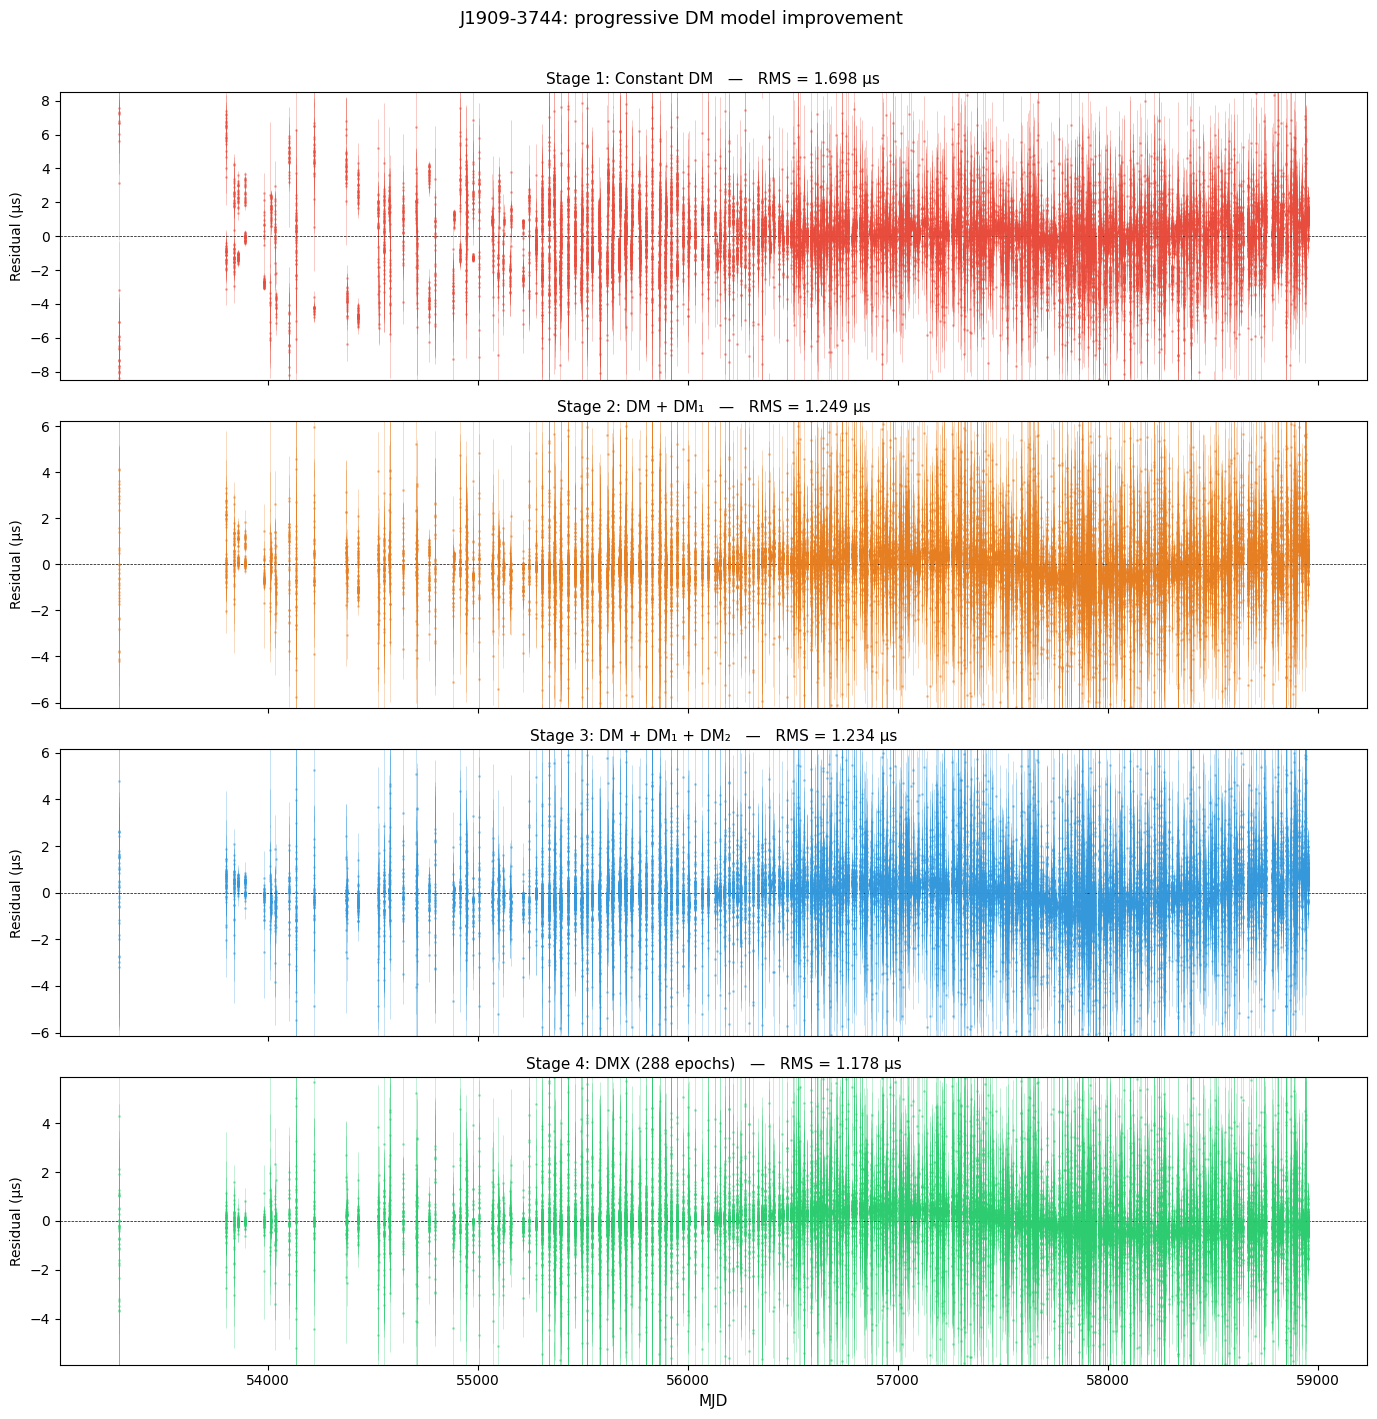

In [7]:
fits   = [fit1, fit2, fit3, fit4]
labels = ['Stage 1: Constant DM',
          'Stage 2: DM + DM\u2081',
          'Stage 3: DM + DM\u2081 + DM\u2082',
          'Stage 4: DMX (288 epochs)']
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

for ax, fit, label, color in zip(axes, fits, labels, colors):
    mjd = np.array(fit['tdb_mjd'])
    res = np.array(fit['residuals_us'])
    err = np.array(fit['errors_us'])
    rms = np.sqrt(np.mean(res**2))
    ax.errorbar(mjd, res, err, fmt='.', ms=2, alpha=0.4,
                color=color, elinewidth=0.5)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_ylabel('Residual (µs)', fontsize=10)
    ax.set_title(f"{label}   —   RMS = {rms:.3f} µs", fontsize=11)
    ylim = min(5 * rms, 30)
    ax.set_ylim(-ylim, ylim)

axes[-1].set_xlabel('MJD', fontsize=11)
fig.suptitle('J1909-3744: progressive DM model improvement',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## DM time series: what DMX resolves

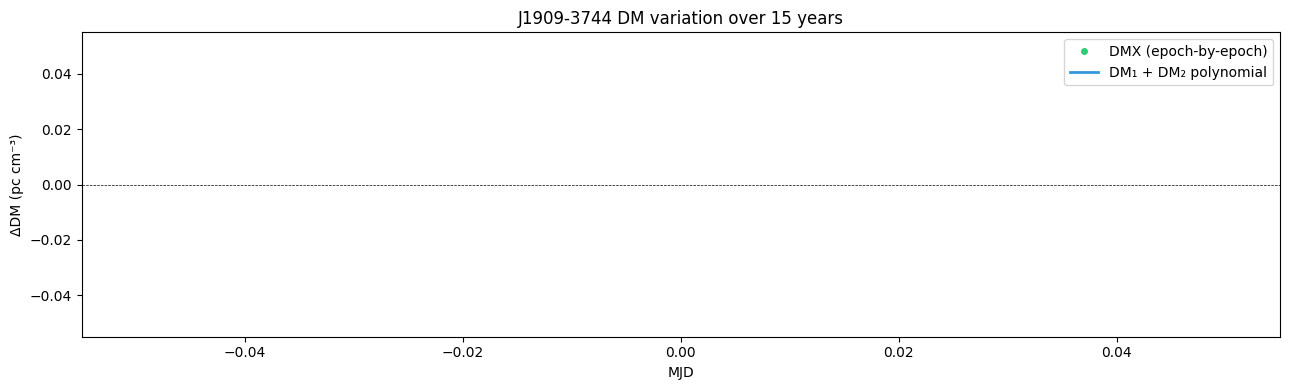

In [8]:
# Extract DMX values from the fitted full-par session
dmx_keys = sorted([k for k in fit4['final_params'] if k.startswith('DMX_')])
dmx_mjd  = []
dmx_val  = []
for k in dmx_keys:
    idx = k.split('_')[1]
    r1_key = f'DMXR1_{idx}'
    r2_key = f'DMXR2_{idx}'
    if r1_key in s4.params and r2_key in s4.params:
        mid = (s4.params[r1_key] + s4.params[r2_key]) / 2
        dmx_mjd.append(mid)
        dmx_val.append(fit4['final_params'][k])

dmx_mjd = np.array(dmx_mjd)
dmx_val = np.array(dmx_val)

# DM polynomial from stage 3
dm0   = s3.params['DM']
dm1   = fit3['final_params']['DM1']
dm2   = fit3['final_params']['DM2']
epoch = s3.params.get('DMEPOCH', 56121.0)
t_yr  = (dmx_mjd - epoch) / 365.25
dm_poly = dm0 + dm1 * t_yr + 0.5 * dm2 * t_yr**2

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(dmx_mjd, dmx_val, 'o', ms=4, color='#2ecc71', label='DMX (epoch-by-epoch)', zorder=5)
ax.plot(dmx_mjd, dm_poly - dm0, '-', color='#3498db', lw=2,
        label='DM\u2081 + DM\u2082 polynomial')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('MJD')
ax.set_ylabel('\u0394DM (pc cm\u207b\u00b3)')
ax.set_title('J1909-3744 DM variation over 15 years')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

Stage                                    RMS (µs)    × worse than DMX
------------------------------------------------------------------------
Stage 1: Constant DM                        1.698                 1.4×
Stage 2: DM + DM₁                           1.249                 1.1×
Stage 3: DM + DM₁ + DM₂                     1.234                 1.0×
Stage 4: DMX (288 epochs)                   1.178                 1.0×


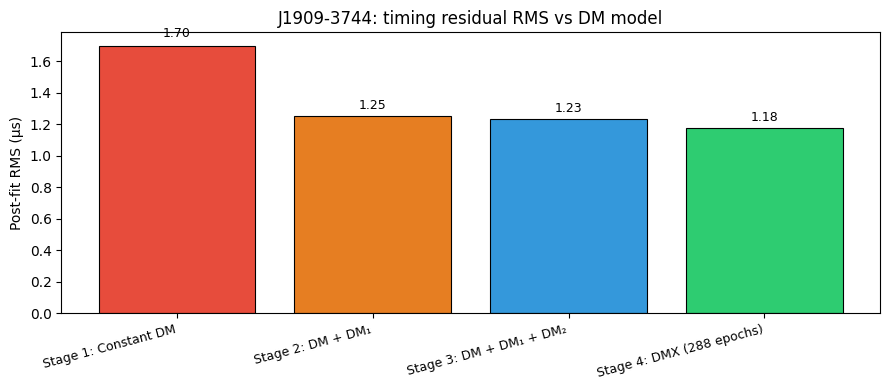

In [9]:
rms_vals = [np.sqrt(np.mean(np.array(f['residuals_us'])**2)) for f in fits]
best = rms_vals[-1]

print(f"{'Stage':<38} {'RMS (µs)':>10}  {'× worse than DMX':>18}")
print('-' * 72)
for label, rms in zip(labels, rms_vals):
    ratio = rms / best
    print(f"{label:<38} {rms:>10.3f}  {ratio:>18.1f}×")

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(4), rms_vals, color=colors, edgecolor='k', linewidth=0.8)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Post-fit RMS (µs)')
ax.set_title('J1909-3744: timing residual RMS vs DM model')
for bar, rms in zip(bars, rms_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'{rms:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Takeaway

- All four stages fit the **same** binary, astrometry, and spin parameters.  The only
  difference is how much DM variation is tracked.
- **Constant DM** leaves µs-level residuals driven by the ISM line-of-sight drift.
- **DM₁** absorbs the linear trend in ~15-year data; **DM₁ + DM₂** removes curvature.
  Neither captures the stochastic epoch-to-epoch scatter visible in the DMX plot.
- **DMX** fits an independent DM per ~30-day epoch, removing essentially all dispersive
  delay and leaving only measurement noise.
- In JUG, switching between models is a single `session.set_free()` call — no par file
  editing needed.